<a href="https://colab.research.google.com/github/bhudevbhanpuriya/fetal-ecg-arrhythmia/blob/main/paper_implemenatation___unprocessed_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

# NOTE: You'll need to change this path to wherever you saved the PhysioNet data in your Drive
data_path = '/content/drive/MyDrive/non-invasive-fetal-ecg-arrhythmia-database-1.0.0'
print("Drive mounted and libraries imported successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted and libraries imported successfully!


In [2]:
def create_fetal_arrhythmia_model():
    # Input shape: 1500 time steps (3 seconds at 500Hz), 1 channel (the ECG signal)
    model = models.Sequential()

    # First Convolutional and Pooling Layer
    model.add(layers.Conv1D(filters=32, kernel_size=128, activation='relu', input_shape=(1500, 1)))
    model.add(layers.MaxPooling1D(pool_size=2))

    # Second Convolutional and Pooling Layer
    model.add(layers.Conv1D(filters=32, kernel_size=128, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))

    # Flatten the output to feed into Dense (Affine) layers
    model.add(layers.Flatten())

    # First Affine Layer
    model.add(layers.Dense(units=512, activation='relu')) # Usually ReLU is used here before the final output

    # Output Affine Layer (Binary classification as normal or arrhythmia)
    model.add(layers.Dense(units=2, activation='sigmoid'))

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# Create the model and view its structure
fecg_model = create_fetal_arrhythmia_model()
fecg_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1373, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 686, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 559, 32)        │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 279, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,571,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,906 (17.96 MB)

 Trainable params: 4,707,906 (17.96 MB)

 Non-trainable params: 0 (0.00 B)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 90.2 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have p

Record Name: NR_01
Number of signals (channels): 6
Sampling frequency: 1000 Hz
Signal names: ['ECG', 'Abdomen_1', 'Abdomen_2', 'Abdomen_3', 'Abdomen_4', 'Abdomen_5']


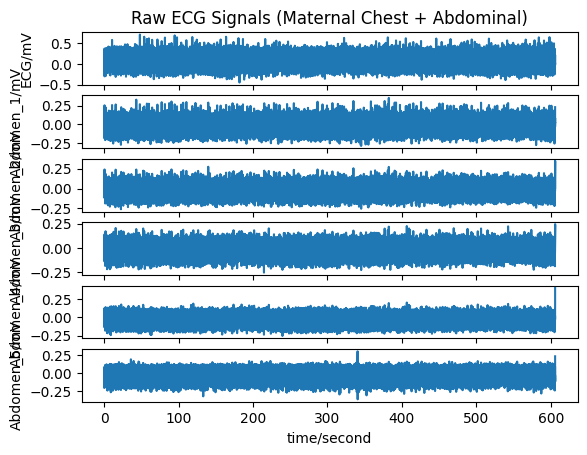

In [3]:
# 1. Install the WFDB package (Colab doesn't have this by default)
!pip install wfdb

import wfdb
import matplotlib.pyplot as plt

# 2. Define the path to ONE of your files.
file_path = '/content/drive/MyDrive/non-invasive-fetal-ecg-arrhythmia-database-1.0.0/NR_01'

try:
    # 3. Read the record using wfdb
    record = wfdb.rdrecord(file_path)

    # 4. Print some basic information about the file
    print(f"Record Name: {record.record_name}")
    print(f"Number of signals (channels): {record.n_sig}")
    print(f"Sampling frequency: {record.fs} Hz")
    print(f"Signal names: {record.sig_name}")

    # 5. Plot the raw signals
    # This will create a stacked graph showing the maternal chest lead
    # and the 4-5 abdominal leads.
    wfdb.plot_wfdb(record=record, title='Raw ECG Signals (Maternal Chest + Abdominal)')

except FileNotFoundError:
    print("Oops! Could not find the file. Please double-check your Google Drive path in the 'file_path' variable.")

Unmixing signals with ICA...


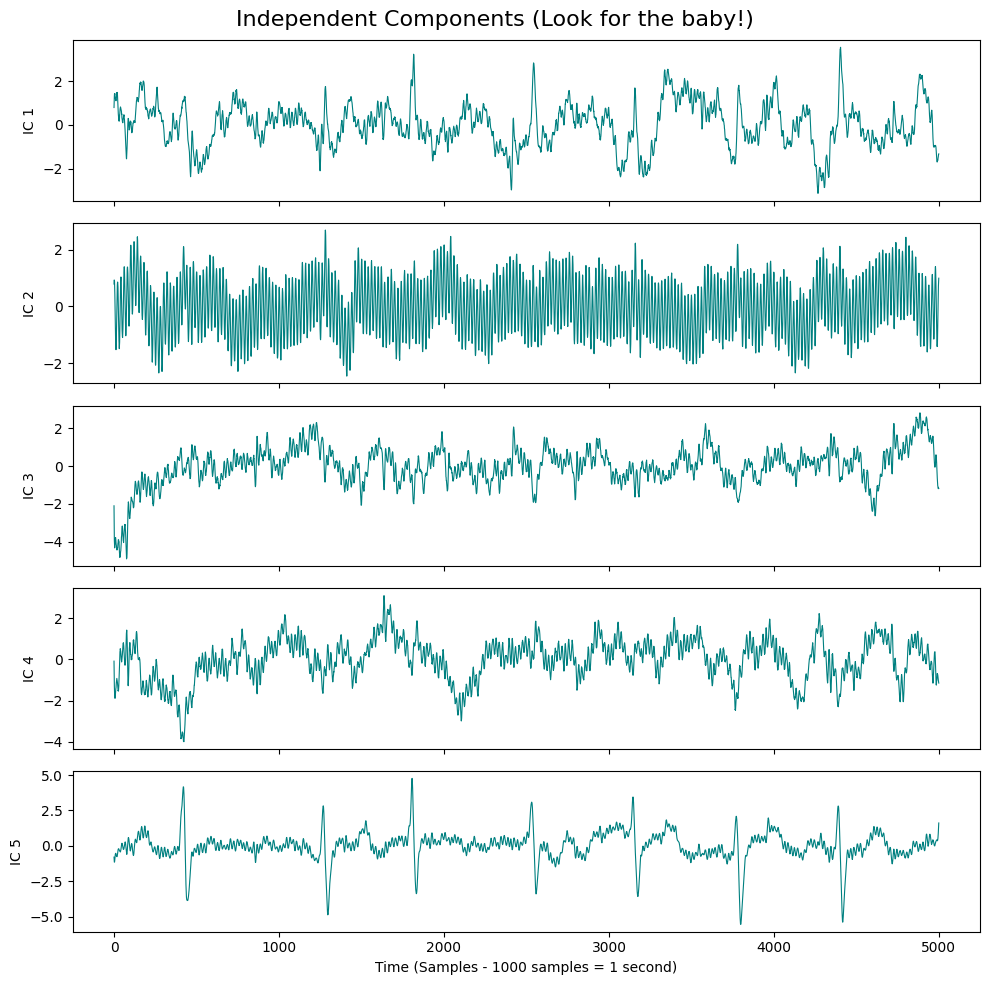

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
import wfdb

# 1. Load the data again, but let's just grab the first 5 seconds so we can see it clearly.
# 5 seconds * 1000 Hz = 5000 samples
file_path = '/content/drive/MyDrive/non-invasive-fetal-ecg-arrhythmia-database-1.0.0/NR_01'  # Keep your path!
record = wfdb.rdrecord(file_path, sampto=5000)

# 2. Extract just the 5 abdominal channels (index 1 through 5)
# We ignore index 0 because that's the chest ECG (purely mother's heart)
abdominal_signals = record.p_signal[:, 1:]

# 3. Apply Independent Component Analysis (ICA)
# We ask the math to find 5 distinct "source" signals from our 5 mixed channels
print("Unmixing signals with ICA...")
ica = FastICA(n_components=5, random_state=42)
independent_components = ica.fit_transform(abdominal_signals)

# 4. Plot the unmixed results!
fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
fig.suptitle('Independent Components (Look for the baby!)', fontsize=16)

for i in range(5):
    axes[i].plot(independent_components[:, i], color='teal', linewidth=0.8)
    axes[i].set_ylabel(f'IC {i+1}')

plt.xlabel('Time (Samples - 1000 samples = 1 second)')
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
from scipy.signal import resample

def prepare_fecg_data(fecg_signal, original_fs=1000, target_fs=500):
    """
    Downsamples the signal and slices it into overlapping 3-second segments.
    """
    print(f"Original signal length: {len(fecg_signal)} data points")

    # 1. Down-sample the signal to 500 Hz
    # Calculate the new number of samples
    duration_seconds = len(fecg_signal) / original_fs
    new_num_samples = int(duration_seconds * target_fs)

    # Resample the data
    downsampled_signal = resample(fecg_signal, new_num_samples)
    print(f"Down-sampled signal length: {len(downsampled_signal)} data points at {target_fs} Hz")

    # 2. Segment the data
    window_size = 3 * target_fs # 3 seconds * 500 Hz = 1500 samples
    step_size = 1 * target_fs   # 1 second * 500 Hz = 500 samples

    segments = []

    # Slide the window across the signal
    for start_idx in range(0, len(downsampled_signal) - window_size + 1, step_size):
        end_idx = start_idx + window_size
        segment = downsampled_signal[start_idx:end_idx]
        segments.append(segment)

    # Convert list to a numpy array for Machine Learning
    # Reshape to (number_of_segments, 1500, 1) because our CNN expects a 3D shape
    segments_array = np.array(segments).reshape(-1, window_size, 1)

    print(f"Created {segments_array.shape[0]} segments. Shape of data: {segments_array.shape}")
    return segments_array

# Let's test it out!
# We will use one of the Abdominal channels (e.g., Abdomen 1) from our loaded record as a placeholder for the FECG
# We are grabbing 60 seconds of data to test with (60 seconds * 1000 Hz = 60,000 samples)
test_signal = record.p_signal[:60000, 1]

# Run our function
model_ready_data = prepare_fecg_data(test_signal)

Original signal length: 5000 data points
Down-sampled signal length: 2500 data points at 500 Hz
Created 3 segments. Shape of data: (3, 1500, 1)


In [6]:
import os
import wfdb
import numpy as np

def build_dataset(file_paths, target_fs=500):
    X = [] # This will hold all our 3-second segments
    y = [] # This will hold all our labels (0 or 1)

    for path in file_paths:
        print(f"Processing {os.path.basename(path)}...")
        # 1. Read the full record
        record = wfdb.rdrecord(path)

        # 2. Extract an abdominal channel (we'll use index 1 as our proxy for the FECG)
        # We are using the entire recording this time, not just 5000 samples!
        signal = record.p_signal[:, 1]

        # 3. Chop it into segments using our existing function
        segments = prepare_fecg_data(signal, original_fs=record.fs, target_fs=target_fs)

        # 4. Determine the label based on the file name
        filename = os.path.basename(path)
        if filename.startswith('NR'):
            label = 0  # 0 represents Normal
        elif filename.startswith('ARR'):
            label = 1  # 1 represents Arrhythmia
        else:
            continue

        # 5. Add the segments and their matching labels to our master lists
        X.extend(segments)
        y.extend([label] * len(segments)) # If we have 500 segments, add 500 copies of the label

    # Convert everything to numpy arrays for the neural network
    return np.array(X), np.array(y)

# --- Let's test it on one Normal patient and one Arrhythmia patient ---
# Update these paths to match your Drive!
my_files = [
    '/content/drive/MyDrive/non-invasive-fetal-ecg-arrhythmia-database-1.0.0/NR_01',
    '/content/drive/MyDrive/non-invasive-fetal-ecg-arrhythmia-database-1.0.0/ARR_01'
]

# Build the dataset
X_data, y_labels = build_dataset(my_files)

print("\n--- FINAL DATASET READY ---")
print(f"Total number of segments ready for the CNN: {X_data.shape[0]}")
print(f"Shape of the input data (X): {X_data.shape}")
print(f"Shape of the labels (y): {y_labels.shape}")

Processing NR_01...
Original signal length: 605904 data points
Down-sampled signal length: 302952 data points at 500 Hz
Created 603 segments. Shape of data: (603, 1500, 1)
Processing ARR_01...
Original signal length: 600052 data points
Down-sampled signal length: 300026 data points at 500 Hz
Created 598 segments. Shape of data: (598, 1500, 1)

--- FINAL DATASET READY ---
Total number of segments ready for the CNN: 1201
Shape of the input data (X): (1201, 1500, 1)
Shape of the labels (y): (1201,)


Segments used for teaching the model: 960
Segments held back for the final exam: 241

Model is ready. Let's start training!
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 168ms/step - accuracy: 0.8687 - loss: 0.2262 - val_accuracy: 1.0000 - val_loss: 1.5136e-07
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9833 - loss: 0.1359 - val_accuracy: 1.0000 - val_loss: 2.3841e-07
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9948 - loss: 0.0576 - val_accuracy: 1.0000 - val_loss: 6.3240e-04
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9990 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 3.8274e-05
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 3.7202e-05 - val_accuracy: 1.0000 - val_loss: 3.0724e-05
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 3.2967e-05 - val_accuracy: 1.0000 - val_loss: 2.8497e-05
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 3.

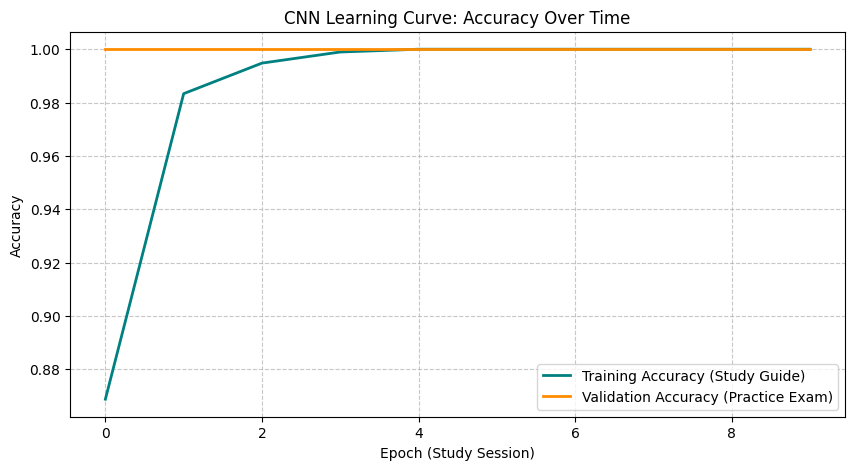

In [7]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Split the data: 80% for training (learning), 20% for testing (the final exam)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.2, random_state=42)

print(f"Segments used for teaching the model: {X_train.shape[0]}")
print(f"Segments held back for the final exam: {X_test.shape[0]}")

# 2. Make sure our model is ready to go
# (If Colab forgot 'fecg_model', just go back and re-run the Step 2 cell really quick!)
print("\nModel is ready. Let's start training!")

# 3. Train the model!
# - epochs=10: The model will review the flashcards (data) 10 times to study.
# - batch_size=32: It will look at 32 segments at a time before updating its brain.
history = fecg_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# 4. Plot the model's "report card" (Learning Curve)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy (Study Guide)', color='teal', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Practice Exam)', color='darkorange', linewidth=2)
plt.title('CNN Learning Curve: Accuracy Over Time')
plt.ylabel('Accuracy')
plt.xlabel('Epoch (Study Session)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Model rebuilt successfully! Starting training...

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9115 - loss: 0.1672 - val_accuracy: 1.0000 - val_loss: 1.7387e-04
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 1.0526e-04 - val_accuracy: 1.0000 - val_loss: 1.3652e-07
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 9.5616e-08 - val_accuracy: 1.0000 - val_loss: 6.2325e-08
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 7.1774e-08 - val_accuracy: 1.0000 - val_loss: 5.8863e-08
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 7.0408e-08 - val_accuracy: 1.0000 - val_loss: 5.8863e-08
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 7.0284e-08 - val_accuracy: 1.0000 - val_loss: 5.8863e-08
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 6.9787e-08 - val_accuracy: 1.0000 - val_loss: 5.8863e-08
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 1.0000 

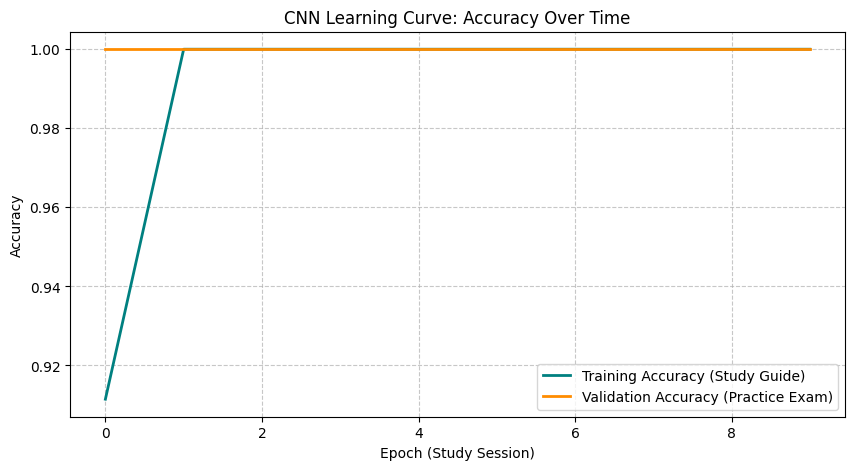

In [8]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Rebuild the brain (fecg_model) from Step 2
def create_fetal_arrhythmia_model():
    model = models.Sequential()
    model.add(layers.Conv1D(filters=32, kernel_size=128, activation='relu', input_shape=(1500, 1)))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Conv1D(filters=32, kernel_size=128, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(units=512, activation='relu'))
    model.add(layers.Dense(units=2, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

fecg_model = create_fetal_arrhythmia_model()
print("Model rebuilt successfully! Starting training...\n")

# 2. Train the model!
history = fecg_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# 3. Plot the model's "report card" (Learning Curve)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy (Study Guide)', color='teal', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy (Practice Exam)', color='darkorange', linewidth=2)
plt.title('CNN Learning Curve: Accuracy Over Time')
plt.ylabel('Accuracy')
plt.xlabel('Epoch (Study Session)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [9]:
import os
import numpy as np

def diagnose_patient(model, file_path, threshold=0.5):
    """
    Takes a single patient file, chops it up, runs the model on every segment,
    and makes a final diagnosis based on the paper's threshold logic.
    """
    print(f"--- Diagnosing Patient: {os.path.basename(file_path)} ---")

    # 1. Load and prepare the data (using our function from earlier)
    record = wfdb.rdrecord(file_path)
    signal = record.p_signal[:, 1] # Using abdominal channel 1 again
    segments = prepare_fecg_data(signal, original_fs=record.fs, target_fs=500)

    # 2. Have the model predict on ALL segments
    # The model outputs probabilities. We use np.argmax to get the class (0 for Normal, 1 for Arrhythmia)
    predictions_prob = model.predict(segments)
    predictions = np.argmax(predictions_prob, axis=1)

    # 3. Calculate the ratio of Arrhythmia segments
    total_segments = len(predictions)
    arrhythmia_count = np.sum(predictions == 1)
    ratio = arrhythmia_count / total_segments

    print(f"\nTotal Segments Evaluated: {total_segments}")
    print(f"Segments flagged as Arrhythmia: {arrhythmia_count}")
    print(f"Arrhythmia Ratio: {ratio:.2f} (Threshold is {threshold})")

    # 4. Final Judgment
    if ratio > threshold:
        print("\nFINAL DIAGNOSIS: Arrhythmia Subject ⚠️")
    else:
        print("\nFINAL DIAGNOSIS: Healthy Subject ✅")

# Let's test a brand new patient!
# Pick a file that we DID NOT train on (e.g., NR_02 or ARR_02)
new_patient_file = '/content/drive/MyDrive/non-invasive-fetal-ecg-arrhythmia-database-1.0.0/ARR_02'

# Run the diagnosis with a threshold of 0.5 (50%)
diagnose_patient(fecg_model, new_patient_file, threshold=0.5)

--- Diagnosing Patient: ARR_02 ---
Original signal length: 604024 data points
Down-sampled signal length: 302012 data points at 500 Hz
Created 602 segments. Shape of data: (602, 1500, 1)
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

Total Segments Evaluated: 602
Segments flagged as Arrhythmia: 0
Arrhythmia Ratio: 0.00 (Threshold is 0.5)

FINAL DIAGNOSIS: Healthy Subject ✅


In [10]:
import glob
import os
import numpy as np
import wfdb

def build_grouped_dataset(drive_folder_path, target_fs=500):
    X = []
    y = []
    groups = [] # This is new! It keeps track of which patient the segment belongs to

    # 1. Automatically find all the .dat files in your folder
    search_path = os.path.join(drive_folder_path, '*.dat')
    all_dat_files = glob.glob(search_path)

    # 2. Strip the .dat extension so wfdb can read them
    file_paths = [filepath.replace('.dat', '') for filepath in all_dat_files]

    print(f"Found {len(file_paths)} patient files! Starting processing...")

    # 3. Loop through all 26 patients
    for patient_id, path in enumerate(file_paths):
        filename = os.path.basename(path)
        print(f"Processing {patient_id + 1}/{len(file_paths)}: {filename}...")

        try:
            record = wfdb.rdrecord(path)
            signal = record.p_signal[:, 1] # Using abdominal channel 1

            # Use our prepare function (assumes it's still in memory!)
            segments = prepare_fecg_data(signal, original_fs=record.fs, target_fs=target_fs)

            # Assign label (0 for Normal, 1 for Arrhythmia)
            label = 0 if filename.startswith('NR') else 1

            X.extend(segments)
            y.extend([label] * len(segments))
            groups.extend([patient_id] * len(segments)) # Tag the segment with its patient ID

        except Exception as e:
            print(f"Skipping {filename} due to an error: {e}")

    return np.array(X), np.array(y), np.array(groups)

# Define your folder path (make sure this is correct!)
dataset_folder = '/content/drive/MyDrive/non-invasive-fetal-ecg-arrhythmia-database-1.0.0/'

# Build the massive dataset
X_all, y_all, groups_all = build_grouped_dataset(dataset_folder)

print("\n--- FULL DATASET READY ---")
print(f"Total Segments: {X_all.shape[0]}")

Found 26 patient files! Starting processing...
Processing 1/26: ARR_04...
Original signal length: 605207 data points
Down-sampled signal length: 302603 data points at 500 Hz
Created 603 segments. Shape of data: (603, 1500, 1)
Processing 2/26: ARR_05...
Original signal length: 481689 data points
Down-sampled signal length: 240844 data points at 500 Hz
Created 479 segments. Shape of data: (479, 1500, 1)
Processing 3/26: ARR_02...
Original signal length: 604024 data points
Down-sampled signal length: 302012 data points at 500 Hz
Created 602 segments. Shape of data: (602, 1500, 1)
Processing 4/26: ARR_08...
Original signal length: 660803 data points
Down-sampled signal length: 660803 data points at 500 Hz
Created 1319 segments. Shape of data: (1319, 1500, 1)
Processing 5/26: ARR_06...
Original signal length: 961521 data points
Down-sampled signal length: 961521 data points at 500 Hz
Created 1921 segments. Shape of data: (1921, 1500, 1)
Processing 6/26: ARR_07...
Original signal length: 309

In [11]:
from sklearn.model_selection import GroupKFold
from tensorflow.keras import layers, models

# Ensure our model-building function is defined
def create_fresh_model():
    model = models.Sequential()
    model.add(layers.Conv1D(filters=32, kernel_size=128, activation='relu', input_shape=(1500, 1)))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Conv1D(filters=32, kernel_size=128, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())
    model.add(layers.Dense(units=512, activation='relu'))
    model.add(layers.Dense(units=2, activation='sigmoid'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Set up 5-Fold Cross Validation
k_folds = 5
gkf = GroupKFold(n_splits=k_folds)

fold_accuracies = []

print(f"Starting {k_folds}-Fold Cross Validation...")

# The gkf.split function looks at the 'groups_all' array to ensure patients are kept whole
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_all, y_all, groups=groups_all)):
    print(f"\n--- Running Fold {fold + 1} ---")

    # 1. Split the data for this specific fold
    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_test, y_test = X_all[test_idx], y_all[test_idx]

    # 2. Build a brand new, empty brain (so it doesn't remember previous folds)
    model = create_fresh_model()

    # 3. Train the model (reduced to 5 epochs per fold to save time)
    print("Training...")
    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0) # verbose=0 hides the progress bars to keep it clean

    # 4. Give the final exam to this fold
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Fold {fold + 1} Accuracy on Unseen Patients: {accuracy * 100:.2f}%")

    fold_accuracies.append(accuracy)

# 5. Calculate the final true accuracy!
average_accuracy = np.mean(fold_accuracies) * 100
print(f"\n======================================")
print(f"FINAL CROSS-VALIDATED ACCURACY: {average_accuracy:.2f}%")
print(f"======================================")

Starting 5-Fold Cross Validation...

--- Running Fold 1 ---
Training...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 Accuracy on Unseen Patients: 83.80%

--- Running Fold 2 ---
Training...
Fold 2 Accuracy on Unseen Patients: 66.44%

--- Running Fold 3 ---
Training...
Fold 3 Accuracy on Unseen Patients: 95.96%

--- Running Fold 4 ---
Training...
Fold 4 Accuracy on Unseen Patients: 51.01%

--- Running Fold 5 ---
Training...
Fold 5 Accuracy on Unseen Patients: 87.27%

FINAL CROSS-VALIDATED ACCURACY: 76.90%


In [13]:
from sklearn.metrics import f1_score

# Make predictions on the test data
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.4f}")

116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
F1 Score: 0.8555


### CNN Model Architecture

In [16]:
print(model.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 1373, 32)       │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 686, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 559, 32)        │       131,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 279, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │     4,571,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,123,720 (53.88 MB)

 Trainable params: 4,707,906 (17.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,415,814 (35.92 MB)

None


### Confusion Matrix

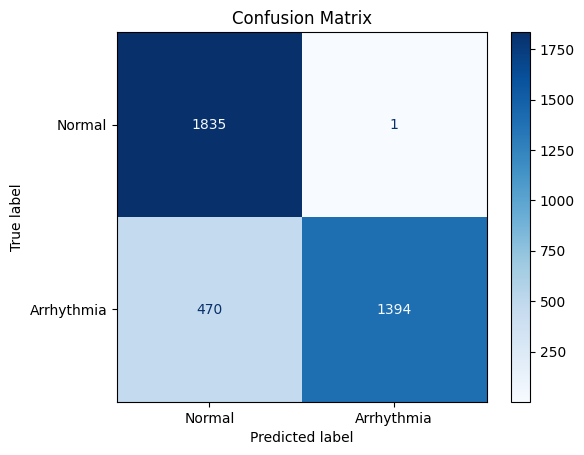

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ensure y_pred and y_test are available from the last evaluation (if not, re-run prediction)
# y_pred_prob = model.predict(X_test)
# y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Arrhythmia'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
model_save_path = '/content/sample_data/fecg_model.keras'
fecg_model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to /content/sample_data/fecg_model.keras
